In [1]:
import pypsa
import numpy as np
import pandas as pd
from pathlib import Path

/home/lukas/micromamba/envs/pypsa-eur/lib/python3.12/site-packages/google/cloud/storage/__init__.py:35: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution
ERROR 1: PROJ: proj_create_from_database: Open of /home/lukas/micromamba/envs/pypsa-eur/share/proj failed


In [2]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc'
)
m = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00_50.nc'
)

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00_50.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


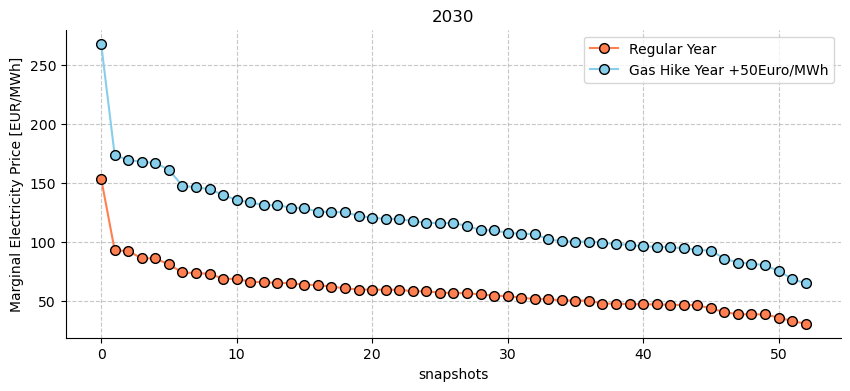

In [24]:
import matplotlib.pyplot as plt

ac_buses = n.buses.index[n.buses.carrier == 'AC']

n.buses_t.marginal_price[ac_buses].mean(axis=1)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    range(len(n.snapshots)),
    n.buses_t.marginal_price[ac_buses].mean(axis=1).sort_values(ascending=False).values,
    marker='o',
    linestyle='-',
    markersize=7,
    color='coral',
    markeredgecolor='k',
    label='Regular Year',
    )

ax.plot(
    range(len(n.snapshots)),
    m.buses_t.marginal_price[ac_buses].mean(axis=1).sort_values(ascending=False).values,
    marker='o',
    linestyle='-',
    markersize=7,
    color='skyblue',
    markeredgecolor='k',
    label='Gas Hike Year +50Euro/MWh',
    )

ax.set_xlabel('snapshots')
ax.set_ylabel('Marginal Electricity Price [EUR/MWh]')
ax.set_title('2030')

ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()